# Wonka Factory, The Final Storytelling Notebook
**Member 3 | The Storyteller**

In [2]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [3]:
dim_products = pd.read_csv("dim_products.csv")
dim_locations = pd.read_csv("dim_locations.csv")
fact_sales = pd.read_csv("fact_sales.csv")

In [4]:
print("dim_products columns:")
print(dim_products.columns.tolist())

print("\ndim_locations columns:")
print(dim_locations.columns.tolist())

print("\nfact_sales columns:")
print(fact_sales.columns.tolist())

dim_products columns:
['product_id', 'product_name', 'division']

dim_locations columns:
['location_id', 'city', 'state_province', 'factory_name', 'coli_index']

fact_sales columns:
['order_id', 'product_id', 'location_id', 'sales', 'cost', 'gross_profit', 'units']


In [5]:
sales = fact_sales.merge(dim_products, on="product_id", how="left").merge(dim_locations,on="location_id",how="left")
sales.head()

,order_id,product_id,location_id,sales,cost,gross_profit,units,product_name,division,city,state_province,factory_name,coli_index
0,1,1,1,7.50,2.60,4.90,2,Wonka Bar - Triple Dazzle Caramel,Chocolate,San Francisco,California,Wicked Choccy's,142.3
1,2,2,2,7.20,2.20,5.00,2,Wonka Bar -Scrumdiddlyumptious,Chocolate,San Francisco,California,Lot's O' Nuts,142.3
2,3,3,3,7.20,2.40,4.80,2,Wonka Bar - Fudge Mallows,Chocolate,New York City,New York,Lot's O' Nuts,125.1
3,4,4,4,9.75,3.42,6.33,3,Wonka Bar - Milk Chocolate,Chocolate,New York City,New York,Wicked Choccy's,125.1
4,5,4,1,6.50,2.28,4.22,2,Wonka Bar - Milk Chocolate,Chocolate,San Francisco,California,Wicked Choccy's,142.3


In [6]:
df_products = (sales.groupby(["product_name", "division"], as_index=False).agg(total_sales=("sales", "sum"), total_cost=("cost", "sum"), total_profit=("gross_profit", "sum"),total_units=("units", "sum")))
df_products["profit_margin_pct"] = (df_products["total_profit"] / df_products["total_sales"] * 100).round(2)
df_products = df_products.sort_values("total_profit", ascending=False)
df_products["label"] = df_products["product_name"] + " (" + df_products["division"] + ")"

top3 = df_products.head(3)
bottom3 = df_products.tail(3)
df_money_story = pd.concat([top3, bottom3]).reset_index(drop=True)

df_products

,product_name,division,total_sales,total_cost,total_profit,total_units,profit_margin_pct,label
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,26424.00,8074.00,18350.00,7340,69.44,Wonka Bar -Scrumdiddlyumptious (Chocolate)
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,27251.25,9447.10,17804.15,7267,65.33,Wonka Bar - Triple Dazzle Caramel (Chocolate)
10,Wonka Bar - Milk Chocolate,Chocolate,25424.75,8918.22,16506.53,7823,64.92,Wonka Bar - Milk Chocolate (Chocolate)
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,22580.30,6470.00,16110.30,6470,71.35,Wonka Bar - Nutty Crunch Surprise (Chocolate)
9,Wonka Bar - Fudge Mallows,Chocolate,23922.00,7974.00,15948.00,6645,66.67,Wonka Bar - Fudge Mallows (Chocolate)
6,Lickable Wallpaper,Other,7580.00,3790.00,3790.00,379,50.00,Lickable Wallpaper (Other)
14,Wonka Gum,Other,597.50,286.80,310.70,478,52.00,Wonka Gum (Other)
0,Everlasting Gobstopper,Sugar,130.00,26.00,104.00,13,80.00,Everlasting Gobstopper (Sugar)
4,Kazookles,Other,1205.75,1113.00,92.75,371,7.69,Kazookles (Other)
3,Hair Toffee,Sugar,76.50,17.00,59.50,17,77.78,Hair Toffee (Sugar)


## Chart 1: Money Makers vs Underperformers

##  Product Profitability Finding

- The top three products are Wonka's strongest money makers.

- These products should be prioritized for production, marketing, and distribution.

- The bottom three products are underperformers and should be reviewed for possible pricing changes, production reduction, or discontinuation.

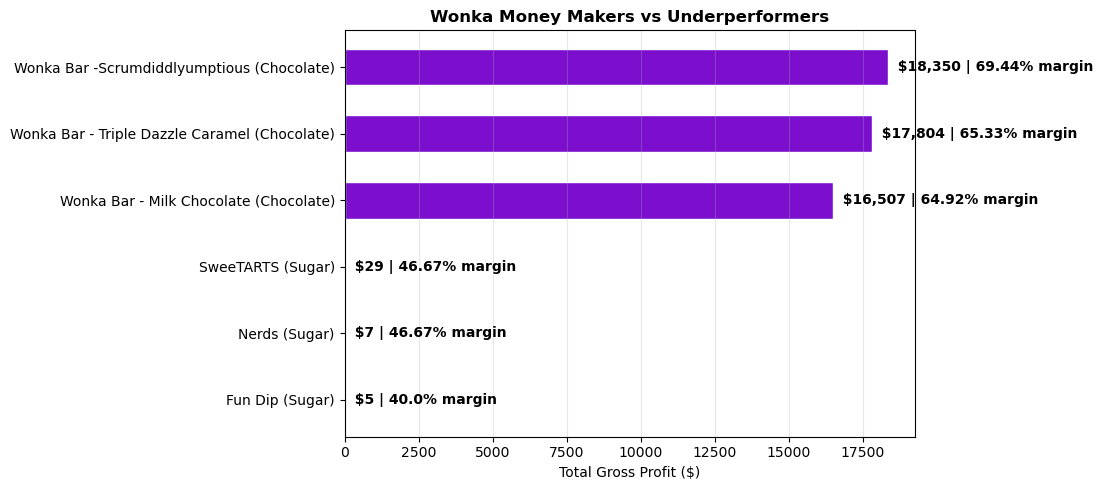

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = []

for i in range(len(df_money_story)):
    if i < 3:
        bar_colors.append("#7b0fcd")
    else:
        bar_colors.append("#e74c3c")

bars = ax.barh(df_money_story["label"],df_money_story["total_profit"],color=bar_colors,edgecolor="white", height=0.55)

for bar, (_, row) in zip(bars, df_money_story.iterrows()):
    ax.text(bar.get_width(),bar.get_y() + bar.get_height() / 2,f'  ${row["total_profit"]:,.0f} | {row["profit_margin_pct"]}% margin', va="center",fontsize=10, color="black", fontweight="bold"), ax.set_xlabel("Total Gross Profit ($)")
ax.set_title("Wonka Money Makers vs Underperformers", fontweight="bold")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
df_region = (sales.groupby(["state_province", "factory_name", "coli_index"], as_index=False).agg(avg_factory_cost=("cost", "mean"),total_cost=("cost", "sum"),total_sales=("sales", "sum"),total_profit=("gross_profit", "sum")))
df_region

,state_province,factory_name,coli_index,avg_factory_cost,total_cost,total_sales,total_profit
0,Alabama,Lot's O' Nuts,88.6,4.406061,145.40,464.81,319.41
1,Alabama,Secret Factory,88.6,24.933333,74.80,150.00,75.20
2,Alabama,The Other Factory,88.6,16.500000,33.00,35.75,2.75
3,Alabama,Wicked Choccy's,88.6,5.295455,116.50,333.75,217.25
4,Arizona,Lot's O' Nuts,110.7,4.131776,442.10,1425.29,983.19
...,...,...,...,...,...,...,...
172,West Virginia,Wicked Choccy's,88.3,4.390000,8.78,25.25,16.47
173,Wisconsin,Lot's O' Nuts,97.7,4.092982,233.30,757.78,524.48
174,Wisconsin,Secret Factory,97.7,41.440000,207.20,415.00,207.80
175,Wisconsin,Wicked Choccy's,97.7,5.477021,257.42,737.25,479.83


## Chart 2: Factory Cost vs COLI

####  Regional Efficiency Finding

- This chart compares average factory cost against the state's Cost of Living Index.

- Factories with high average cost but only moderate or low COLI scores may have operational inefficiencies.

- These locations should be reviewed because the high costs may not be fully explained by the regional economy.

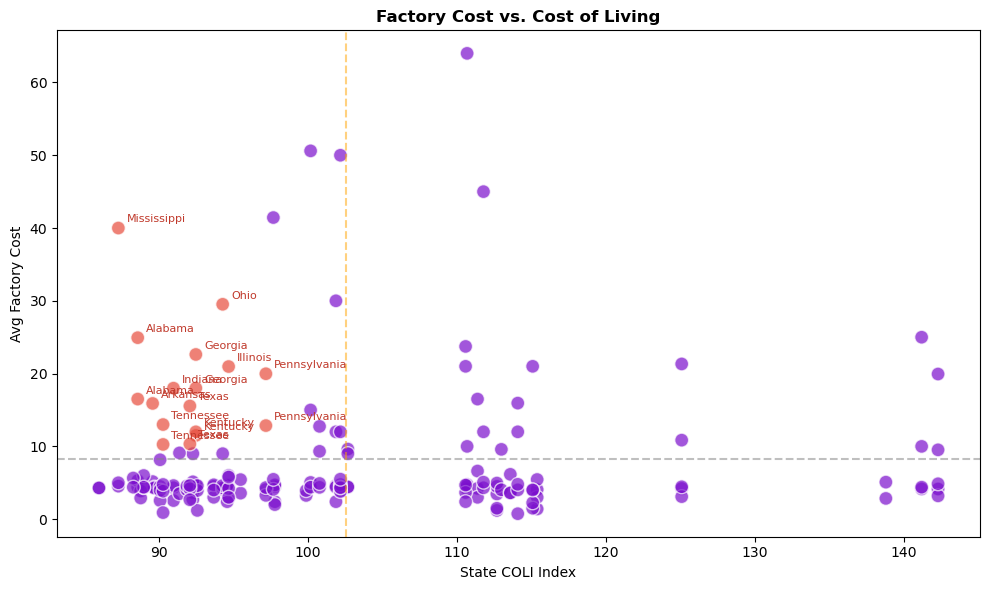

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
avg_cost = df_region["avg_factory_cost"].mean()
avg_coli = df_region["coli_index"].mean()
colors = ["#e74c3c" if (r.avg_factory_cost > avg_cost * 1.15 and r.coli_index < avg_coli * 0.95)
          else "#7b0fcd" for _, r in df_region.iterrows()]

ax.scatter(df_region["coli_index"], df_region["avg_factory_cost"], c=colors, s=100, alpha=0.7, edgecolors="white")
ax.axhline(avg_cost, color="gray", linestyle="--", alpha=0.5)
ax.axvline(avg_coli, color="orange", linestyle="--", alpha=0.5)
for _, r in df_region.iterrows():
    if r.avg_factory_cost > avg_cost * 1.15 and r.coli_index < avg_coli * 0.95:
        ax.annotate(r.state_province, (r.coli_index, r.avg_factory_cost), xytext=(6, 4), textcoords="offset points", fontsize=8, color="#c0392b")

ax.set_xlabel("State COLI Index")
ax.set_ylabel("Avg Factory Cost")
ax.set_title("Factory Cost vs. Cost of Living", fontweight="bold")
plt.tight_layout()
plt.show()

## Final Business Recommendations

**Recommendation 1: Double down on top products**
The bar chart shows a clear gap between money makers and underperformers.
Wonka should concentrate production and marketing on the top 3 flavors.

**Recommendation 2: Cut or reprice the bottom 3 flavors**
The lowest-profit products are dragging down overall margins.
Each should be repriced, reformulated, or discontinued.

**Recommendation 3: Audit high-cost, low-COLI factories**
The scatter plot identifies factories where production costs are
disproportionately high relative to their state's cost of living.
These locations have internal inefficiencies that the local economy cannot explain.

**Recommendation 4: Produce top flavors in efficient regions**
Combine findings from both charts. Manufacture the highest-margin products
in the lowest-cost factories to maximize profit.